In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

np.random.seed(42)
sns.set_style("whitegrid")

# Task 1: Bias Diagnosis — Case Studies

For each of the following scenarios, identify the **type of bias** present (selection bias, survivorship bias, measurement bias, response bias, or another relevant type), explain **how** it distorts the conclusions, and suggest **one concrete fix**.

**Scenario A — App Review Analysis:**
A product team analyzes their app's reviews on the App Store to understand user satisfaction. The average rating is 4.3/5, so they conclude that most users are happy. They plan to reduce investment in customer support.

**Scenario B — Startup Success Study:**
A business school studies 200 successful tech startups (all founded in the last 10 years and still operating) to identify common traits that predict startup success. They find that 80% had a pivot in their first two years and conclude that pivoting is a key success strategy.

**Scenario C — Health Survey:**
A health organization sends a voluntary online survey to 50,000 email subscribers asking about exercise habits and health outcomes. The survey receives 5,000 responses (10% response rate). Results show that respondents exercise an average of 5 hours per week and have excellent self-reported health.

**Scenario D — Salary Benchmarking:**
A recruiting platform publishes average salaries by job title based on user-submitted salary data. The platform is popular among tech workers in large cities. A company in a small town uses this data to set their salary bands.

Write your analysis in markdown cells — no code required for this task. Aim for 3–5 sentences per scenario.

**Scenario A** illustrates **response bias (self‑selection bias)** because only users who voluntarily leave reviews are represented, and they tend to be either very satisfied or very dissatisfied. The team’s conclusion that “most users are happy” is distorted since silent users may have lower satisfaction. This can lead to underinvestment in customer support. A concrete fix is to collect feedback through randomized in‑app surveys or post‑transaction questionnaires so that all types of users are represented.

**Scenario B** is a clear case of **survivorship bias**. The study only looks at startups that survived and ignores the thousands that failed, so the conclusion that “pivoting leads to success” is distorted—many failed startups may also have pivoted. The result is an overestimation of pivoting as a success factor. A concrete fix would be to include both successful and failed startups in the dataset, so the analysis compares traits across the full population rather than just survivors.

**Scenario C** shows **response bias (self‑selection bias)** because only 10% of subscribers chose to respond, and those who did are likely more health‑conscious than average. The conclusion that “people exercise 5 hours per week and have excellent health” is distorted since the silent majority may have very different habits. This leads to an overly optimistic picture of the population’s health. A concrete fix is to use randomized sampling or follow‑up reminders to increase participation and ensure the survey represents all subscribers, not just the most motivated.

**Scenario D** illustrates **selection bias**. The recruiting platform’s salary data comes mainly from tech workers in large cities, so the averages reflect that specific group rather than the broader labor market. The distortion is that a company in a small town may set salary bands far above or below what is realistic locally, leading to misaligned pay structures. A concrete fix would be to supplement user‑submitted data with representative sources such as government labor statistics or region‑specific surveys to ensure salaries are benchmarked against the relevant population.

# Task 2: Create the Population

Before you can study sampling, you need a known population to sample from.

1. Generate a synthetic population of **100,000** individuals with the following columns:
   - `age`: integers drawn from a realistic distribution (e.g., a clipped normal centered at 40 with SD of 15, range 18–85).
   - `income`: correlated with age — use a linear relationship with noise (e.g., `income = 1500 * age + normal_noise`). Clip to a realistic range (e.g., 15,000–250,000).
   - `satisfaction`: a score from 1–10 that depends on income (higher income → slightly higher satisfaction, with plenty of noise).
   - `region`: categorical — randomly assign "Urban" (60%), "Suburban" (25%), "Rural" (15%).
2. Compute and store the **true population parameters**: mean age, mean income, mean satisfaction, and the proportion in each region.
3. Display the population summary and a grid of histograms (one per numerical variable).

These population parameters are your ground truth — everything in the following tasks is measured against them.



In [26]:
# Ensure reproducibility (same random numbers every run)
np.random.seed(42)

# Define population size
N = 100_000

In [27]:
# Generate ages from a normal distribution
# Mean = 40, Standard deviation = 15
age = np.random.normal(loc=40, scale=15, size=N)

# Clip values to realistic human age range (18–85)
age = np.clip(age, 18, 85)

# Convert to integers (since age is discrete)
age = np.round(age).astype(int)


In [28]:
# Add random noise to avoid perfect linear relationship
income_noise = np.random.normal(loc=0, scale=22000, size=N)

# Income increases with age (linear relationship)
income = 1500 * age + income_noise

# Clip income to realistic bounds
income = np.clip(income, 15000, 250000)

In [29]:
# Scale income to range [0, 1]
income_scaled = (income - 15000) / (250000 - 15000)

# Base satisfaction increases slightly with income
# Add noise to make the relationship weak and realistic
satisfaction = 3 + 4 * income_scaled + np.random.normal(0, 1.8, size=N)

# Clip satisfaction to valid range (1–10)
satisfaction = np.clip(satisfaction, 1, 10)

In [30]:
satisfaction

array([7.14191892, 3.11263917, 1.84359538, ..., 2.75572267, 2.08001881,
       2.77410914], shape=(100000,))

In [31]:
# Assign regions with given probabilities
region = np.random.choice(
    ["Urban", "Suburban", "Rural"],
    size=N,
    p=[0.60, 0.25, 0.15]
)

In [32]:
# Combine all variables into a DataFrame
population = pd.DataFrame({
    "age": age,
    "income": income,
    "satisfaction": satisfaction,
    "region": region
})
population

,age,income,satisfaction,region
0,47,93173.080936,7.141919,Suburban
1,38,31582.195125,3.112639,Urban
2,50,87659.618185,1.843595,Urban
3,63,80876.753920,1.621758,Urban
4,36,46797.138260,2.924456,Rural
...,...,...,...,...
99995,37,27679.938224,2.437663,Urban
99996,31,58944.391554,2.510551,Suburban
99997,46,72520.439202,2.755723,Suburban
99998,37,74324.807911,2.080019,Suburban


In [33]:
# Calculate population-level statistics (ground truth)
mean_age = population["age"].mean()
mean_income = population["income"].mean()
mean_satisfaction = population["satisfaction"].mean()

# Proportions of each region
region_proportions = population["region"].value_counts(normalize=True)

In [34]:
# Store all key metrics in a summary table
population_summary = pd.DataFrame({
    "Metric": [
        "Mean age",
        "Mean income",
        "Mean satisfaction",
        "Proportion Urban",
        "Proportion Suburban",
        "Proportion Rural"
    ],
    "Value": [
        mean_age,
        mean_income,
        mean_satisfaction,
        region_proportions.get("Urban", 0),
        region_proportions.get("Suburban", 0),
        region_proportions.get("Rural", 0)
    ]
})

print("Population Summary (Ground Truth):")
print(population_summary)

Population Summary (Ground Truth):
                Metric         Value
0             Mean age     40.480980
1          Mean income  61526.280003
2    Mean satisfaction      3.844207
3     Proportion Urban      0.599270
4  Proportion Suburban      0.250750
5     Proportion Rural      0.149980


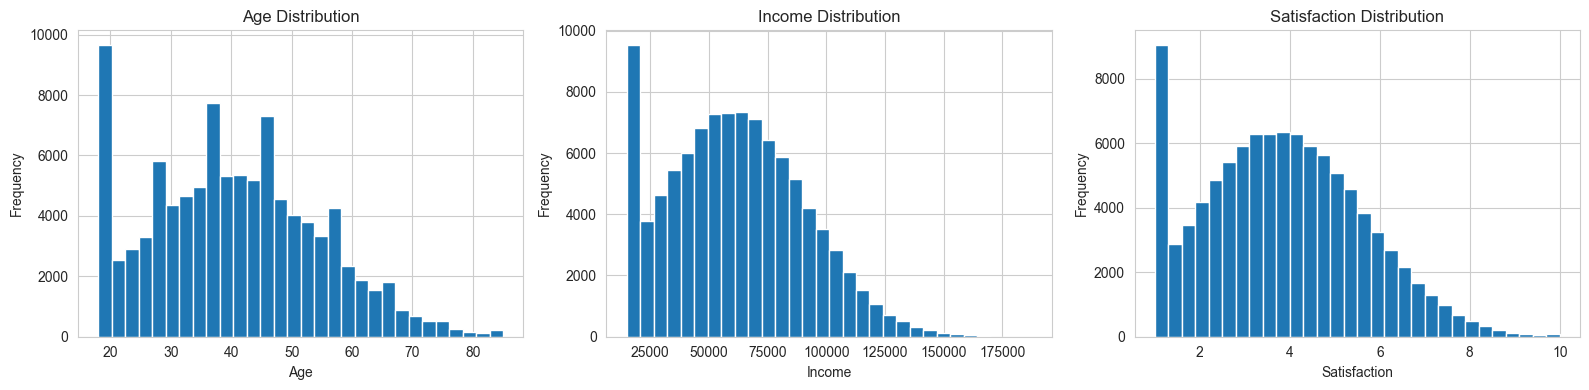

In [35]:
# Create a grid of histograms (one per numeric variable)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Age distribution
axes[0].hist(population["age"], bins=30)
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")

# Income distribution
axes[1].hist(population["income"], bins=30)
axes[1].set_title("Income Distribution")
axes[1].set_xlabel("Income")
axes[1].set_ylabel("Frequency")

# Satisfaction distribution
axes[2].hist(population["satisfaction"], bins=30)
axes[2].set_title("Satisfaction Distribution")
axes[2].set_xlabel("Satisfaction")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Task 3: Biased vs. Unbiased Sampling

Draw samples from your population using three different strategies and compare how well each recovers the true population parameters.

1. **Simple random sample** (n = 200): every individual has an equal chance of being selected.
2. **Biased sample — Urban only** (n = 200): only sample from individuals in the "Urban" region.
3. **Biased sample — High-income filter** (n = 200): only sample from individuals with income above the population median.

For each sample:
- Compute mean age, mean income, and mean satisfaction.
- Display the results alongside the true population parameters in a comparison table.
- Create overlapping KDE plots (sample vs. population) for income and satisfaction.

Now, repeat each sampling strategy **1,000 times** and collect the sample means:
- Plot the **sampling distribution of the mean income** for each strategy (three histograms, side by side).
- Mark the true population mean on each histogram.

**Guiding question:** Which sampling strategies produce biased estimates? How can you tell from the sampling distributions?


In [36]:
# Compute true population parameters
true_mean_age = population["age"].mean()
true_mean_income = population["income"].mean()
true_mean_satisfaction = population["satisfaction"].mean()

# Population median income (needed for high-income biased sample)
income_median = population["income"].median()

In [37]:
# Set random seed for reproducibility
np.random.seed(42)

# 1) Simple random sample
sample_random = population.sample(n=200, random_state=42)

# 2) Biased sample: Urban only
sample_urban = population[population["region"] == "Urban"].sample(n=200, random_state=42)

# 3) Biased sample: income above population median
sample_high_income = population[population["income"] > income_median].sample(n=200, random_state=42)

In [38]:
# Compute summary statistics for each sample
comparison_table = pd.DataFrame({
    "Group": ["Population", "Simple Random", "Urban Only", "High Income Only"],
    "Mean Age": [
        population["age"].mean(),
        sample_random["age"].mean(),
        sample_urban["age"].mean(),
        sample_high_income["age"].mean()
    ],
    "Mean Income": [
        population["income"].mean(),
        sample_random["income"].mean(),
        sample_urban["income"].mean(),
        sample_high_income["income"].mean()
    ],
    "Mean Satisfaction": [
        population["satisfaction"].mean(),
        sample_random["satisfaction"].mean(),
        sample_urban["satisfaction"].mean(),
        sample_high_income["satisfaction"].mean()
    ]
})

print(comparison_table)

              Group  Mean Age   Mean Income  Mean Satisfaction
0        Population  40.48098  61526.280003           3.844207
1     Simple Random  40.72500  63344.583357           3.834241
2        Urban Only  40.14000  61357.346161           3.992245
3  High Income Only  48.06000  84137.439350           4.055937


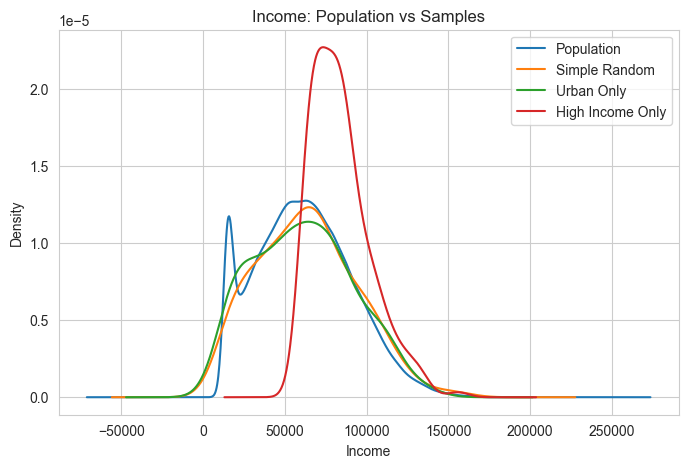

In [39]:
# Plot KDE-like density curves for income
population["income"].plot(kind="density", label="Population", figsize=(8, 5))
sample_random["income"].plot(kind="density", label="Simple Random")
sample_urban["income"].plot(kind="density", label="Urban Only")
sample_high_income["income"].plot(kind="density", label="High Income Only")

plt.title("Income: Population vs Samples")
plt.xlabel("Income")
plt.legend()
plt.show()

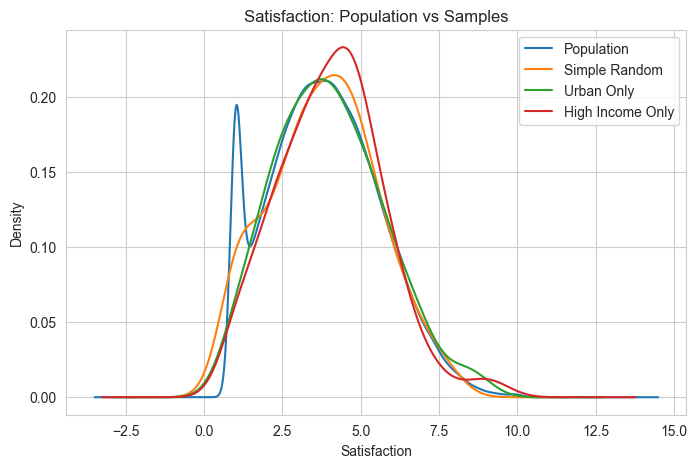

In [40]:
# Plot KDE-like density curves for satisfaction
population["satisfaction"].plot(kind="density", label="Population", figsize=(8, 5))
sample_random["satisfaction"].plot(kind="density", label="Simple Random")
sample_urban["satisfaction"].plot(kind="density", label="Urban Only")
sample_high_income["satisfaction"].plot(kind="density", label="High Income Only")

plt.title("Satisfaction: Population vs Samples")
plt.xlabel("Satisfaction")
plt.legend()
plt.show()

In [41]:
# Number of repetitions
n_reps = 1000

# Empty lists to store sample means
random_income_means = []
urban_income_means = []
high_income_means = []

for i in range(n_reps):
    # Simple random sample
    s1 = population.sample(n=200)
    random_income_means.append(s1["income"].mean())

    # Urban-only sample
    s2 = population[population["region"] == "Urban"].sample(n=200)
    urban_income_means.append(s2["income"].mean())

    # High-income-only sample
    s3 = population[population["income"] > income_median].sample(n=200)
    high_income_means.append(s3["income"].mean())

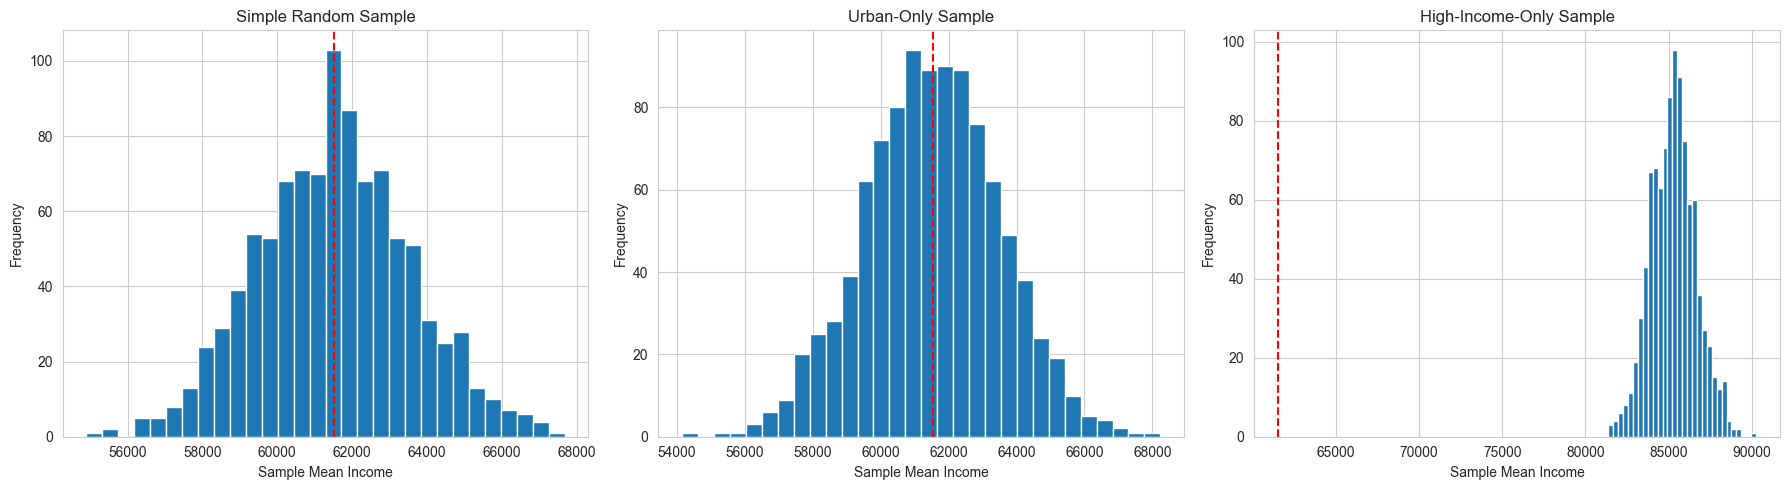

In [42]:
# Plot histograms of sampling distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Simple random sample distribution
axes[0].hist(random_income_means, bins=30)
axes[0].axvline(true_mean_income, linestyle="--", color='red')
axes[0].set_title("Simple Random Sample")
axes[0].set_xlabel("Sample Mean Income")
axes[0].set_ylabel("Frequency")

# Urban-only sample distribution
axes[1].hist(urban_income_means, bins=30)
axes[1].axvline(true_mean_income, linestyle="--", color='red')
axes[1].set_title("Urban-Only Sample")
axes[1].set_xlabel("Sample Mean Income")
axes[1].set_ylabel("Frequency")

# High-income-only sample distribution
axes[2].hist(high_income_means, bins=30)
axes[2].axvline(true_mean_income, linestyle="--", color='red')
axes[2].set_title("High-Income-Only Sample")
axes[2].set_xlabel("Sample Mean Income")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [43]:
# Compare the average sample mean across strategies
sampling_summary = pd.DataFrame({
    "Strategy": ["Simple Random", "Urban Only", "High Income Only"],
    "Average of 1000 Sample Means": [
        np.mean(random_income_means),
        np.mean(urban_income_means),
        np.mean(high_income_means)
    ],
    "True Population Mean Income": [true_mean_income, true_mean_income, true_mean_income]
})

print(sampling_summary)

           Strategy  Average of 1000 Sample Means  True Population Mean Income
0     Simple Random                  61515.998160                 61526.280003
1        Urban Only                  61497.466447                 61526.280003
2  High Income Only                  85272.547713                 61526.280003


### The simple random sampling strategy is unbiased because its sampling distribution is centered around the true population mean. This indicates that, on average, it recovers the correct parameter.

The urban-only sampling strategy introduces slight bias because it excludes part of the population. Its sampling distribution is slightly shifted from the true mean, showing a small systematic error.

The high-income-only sampling strategy is strongly biased because it only includes individuals above the median income. As a result, its sampling distribution is significantly shifted to the right and does not recover the true population mean.

Therefore, a sampling method is biased when its sampling distribution is not centered at the true population parameter.